In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from  sklearn.metrics  import  accuracy_score , precision_score , recall_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [101]:
# load the dataset
loan = pd.read_csv("dataset/loan_data.csv")
loan.head()

,credit_policy,purpose,interest_rate,installment,log_annual_income,debt_income_ratio,credit_score,days_with_cr_line,revol_balance,revol_utilization,inquiry_last_6months,delinquent_2yrs,public_record,not_fully_paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [103]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   credit_policy         9578 non-null   int64  
 1   purpose               9578 non-null   object 
 2   interest_rate         9578 non-null   float64
 3   installment           9578 non-null   float64
 4   log_annual_income     9578 non-null   float64
 5   debt_income_ratio     9578 non-null   float64
 6   credit_score          9578 non-null   int64  
 7   days_with_cr_line     9578 non-null   float64
 8   revol_balance         9578 non-null   int64  
 9   revol_utilization     9578 non-null   float64
 10  inquiry_last_6months  9578 non-null   int64  
 11  delinquent_2yrs       9578 non-null   int64  
 12  public_record         9578 non-null   int64  
 13  not_fully_paid        9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [105]:
# Check how many unique values are there in Purpose column.

loan['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

In [107]:
# encode Purpose column using LabelEncoder.
le = LabelEncoder()
loan['purpose'] = le.fit_transform(loan['purpose'])
loan.head()

,credit_policy,purpose,interest_rate,installment,log_annual_income,debt_income_ratio,credit_score,days_with_cr_line,revol_balance,revol_utilization,inquiry_last_6months,delinquent_2yrs,public_record,not_fully_paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [109]:
# Data Visualization

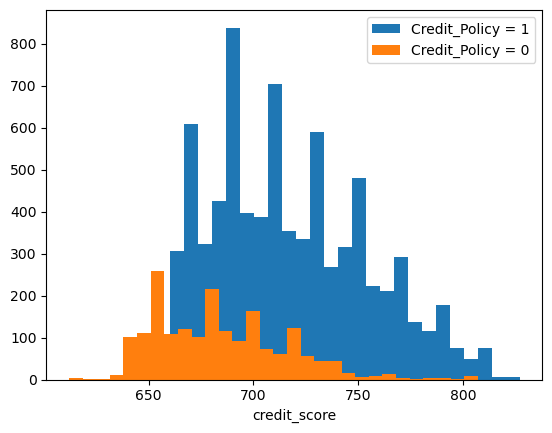

In [111]:
# This checks, does credit score have relation with someone meeting the credit policy.

plt.hist(loan['credit_score'].loc[loan['credit_policy']== 1], bins= 30,  label='Credit_Policy = 1')
plt.hist(loan['credit_score'].loc[loan['credit_policy']== 0], bins= 30,  label='Credit_Policy = 0')
plt.legend()
plt.xlabel('credit_score')
plt.show()

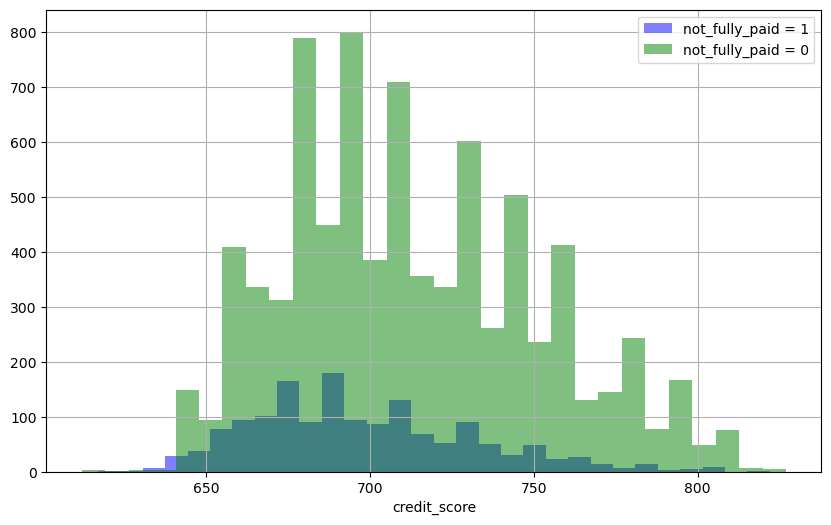

In [113]:
# it shows, the distribution of credit score of users who repaid the loan and who didn't.

plt.figure(figsize=(10,6))
loan[loan['not_fully_paid']== 1]['credit_score'].hist(bins= 30, alpha= 0.5, color='blue', label='not_fully_paid = 1')
loan[loan['not_fully_paid']== 0]['credit_score'].hist(bins= 30, alpha= 0.5, color='green', label='not_fully_paid = 0')
plt.legend()
plt.xlabel('credit_score')
plt.show()

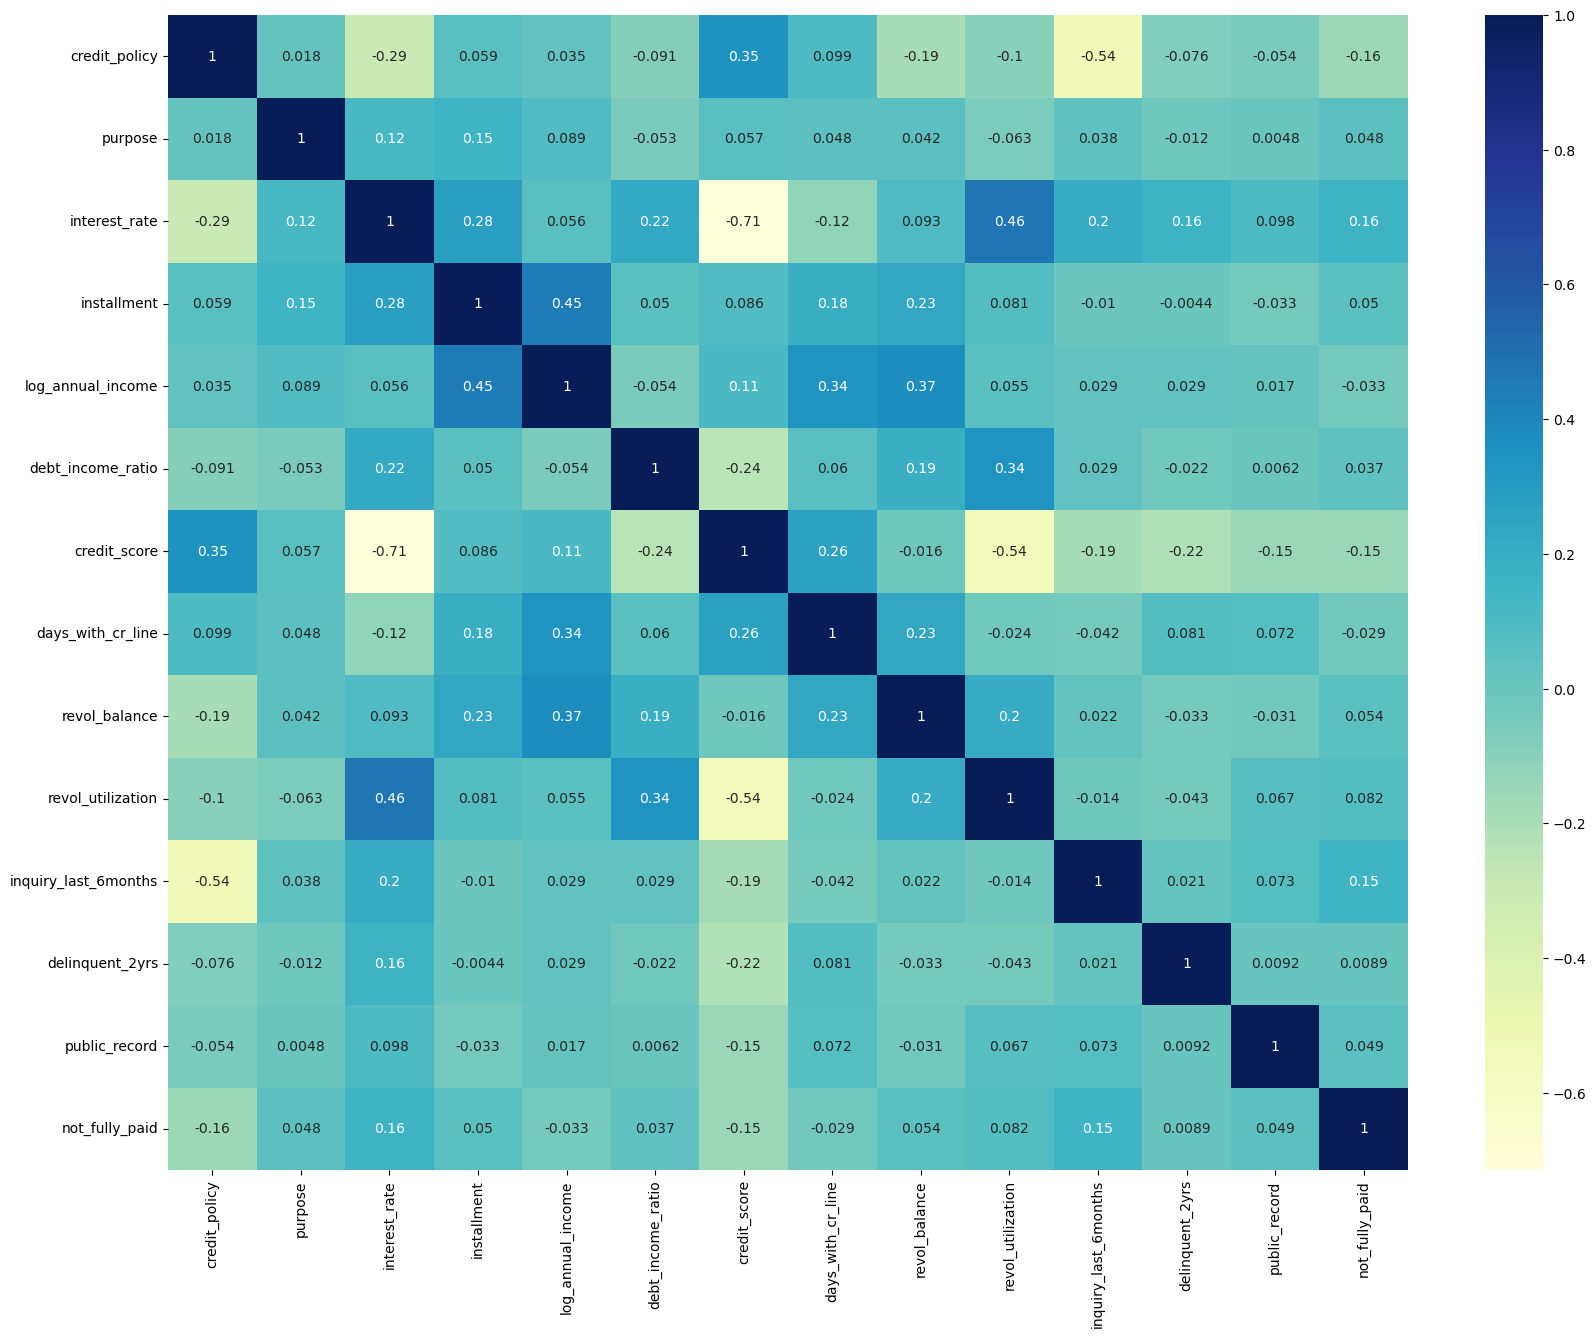

In [115]:
# this calculates the co-relation between all numerical columns in the loan dataframe and display.

plt.figure(figsize = (20, 15)) 
sns.heatmap(loan.corr(), cmap='YlGnBu', annot=True)
plt.show()

In [117]:
X = loan.iloc[:,1:-1]
y = loan.iloc[:,-1]
print(X.shape)
print(y.shape)

(9578, 12)
(9578,)


In [119]:
# train test split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state= 79)

In [131]:
# Modelling using DecisionTree Classifier.

dt_clf = DecisionTreeClassifier()
param_grid = {
    'max_depth': [4,8,12,16,20]
    }
grid = GridSearchCV(dt_clf, param_grid, scoring= 'recall', cv=5)
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [4, 8, 12, 16, 20]}, scoring='recall')

In [133]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20}
0.2116226162596186


In [135]:
y_pred_train = grid.predict(X_train)
y_pred_test = grid.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

In [137]:
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_test))
print("\n")
print("******************Classification Report********************\n")
print(classification_report(y_test,y_pred_test))
print("\n")
print("******************Accuracy Scores******************\n")
print('Train Accuracy score: ',train_accuracy)
print('Test Accuracy score:',test_accuracy)


Confusion Matrix 
 [[1412  195]
 [ 246   63]]


******************Classification Report********************

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1607
           1       0.24      0.20      0.22       309

    accuracy                           0.77      1916
   macro avg       0.55      0.54      0.54      1916
weighted avg       0.75      0.77      0.76      1916



******************Accuracy Scores******************

Train Accuracy score:  0.9684155572957452
Test Accuracy score: 0.7698329853862212


In [139]:
# Modelling using RandomForest Classifier

rf_clf = RandomForestClassifier(n_estimators=300)
rf_clf.fit(X_train, y_train)

y_pred_train = rf_clf.predict(X_train)
y_pred_test = rf_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

In [141]:
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_test))
print("\n")
print("******************Classification Report******************\n")
print(classification_report(y_test,y_pred_test))
print("\n")
print("******************Accuracy Scores******************\n")
print('Train Accuracy score: ',train_accuracy)
print('Test Accuracy score:',test_accuracy)

Confusion Matrix 
 [[1599    8]
 [ 301    8]]


******************Classification Report******************

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1607
           1       0.50      0.03      0.05       309

    accuracy                           0.84      1916
   macro avg       0.67      0.51      0.48      1916
weighted avg       0.79      0.84      0.77      1916



******************Accuracy Scores******************

Train Accuracy score:  1.0
Test Accuracy score: 0.8387265135699373


In [143]:
# modelling using GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(learning_rate = 0.05)
gb_clf.fit(X_train, y_train)

y_pred_train = gb_clf.predict(X_train)
y_pred_test = gb_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

In [145]:
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_test))
print("\n")
print("******************Classification Report******************\n")
print(classification_report(y_test,y_pred_test))
print("\n")
print("******************Accuracy Scores******************\n")
print('Train Accuracy score: ',train_accuracy)
print('Test Accuracy score:',test_accuracy)

Confusion Matrix 
 [[1599    8]
 [ 305    4]]


******************Classification Report******************

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1607
           1       0.33      0.01      0.02       309

    accuracy                           0.84      1916
   macro avg       0.59      0.50      0.47      1916
weighted avg       0.76      0.84      0.77      1916



******************Accuracy Scores******************

Train Accuracy score:  0.847559383972853
Test Accuracy score: 0.8366388308977035


In [147]:
# using pipeline, to decide which model is giving best result.

from sklearn.pipeline import Pipeline

In [151]:
pipeline = Pipeline([
    ("model", DecisionTreeClassifier(max_depth=[4,8,12,16,20]))
])


param_grid = [
    {
        "model":  [DecisionTreeClassifier()],
        "model__max_depth": [4,8,12,16,20]
    },

    {
        "model": [RandomForestClassifier()],
        "model__n_estimators": [200,250,300,350],
        "model__max_depth": [4,8,12,16,20]
    },

    {
        "model": [GradientBoostingClassifier(learning_rate = 0.05)],
        "model__n_estimators": [200,250,300,350],
        "model__max_depth": [4,8,12,16,20]
        
    }
    
]


grid = GridSearchCV(pipeline, param_grid, cv=5 , n_jobs=-1)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('model',
                                        DecisionTreeClassifier(max_depth=[4, 8,
                                                                          12,
                                                                          16,
                                                                          20]))]),
             n_jobs=-1,
             param_grid=[{'model': [DecisionTreeClassifier()],
                          'model__max_depth': [4, 8, 12, 16, 20]},
                         {'model': [RandomForestClassifier()],
                          'model__max_depth': [4, 8, 12, 16, 20],
                          'model__n_estimators': [200, 250, 300, 350]},
                         {'model': [GradientBoostingClassifier(learning_rate=0.05)],
                          'model__max_depth': [4, 8, 12, 16, 20],
                          'model__n_estimators': [200, 250, 300, 350]}])

In [153]:
grid.best_score_

0.8402506050526366

In [162]:
import joblib

joblib.dump(grid.best_estimator_, 'loan_repay_model.pkl')

['loan_repay_model.pkl']

### Conclusion

## without pipeline:
- While I check each classifier separately, Test Accuracy is varying between 76% and 83%.
- There is not much difference in output, between Random Forest and Gradient Boosting.
- It looks like there is an overfitting happening in Decision Tree and Random Forest modelling. Because in both the cases Train and Test accuracy having significant difference.
- So, without pipline, I can conclude that Gradient Boosting Modelling if performing better with 83% test accuracy.

## wih pipeline
- It turned out that, Random Forest Classifier is the better estimator with these parameters(max_depth=4, n_estimators=200).
- and best score of this estimator is 84%